In [189]:
%reset -f

In [190]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [299]:
pd.set_option('display.max_colwidth', None) 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option("display.float_format", "{:.4f}".format) 

In [ ]:
train_df = pd.read_csv("/Users/ashwinkadam/offer-to-sku-mathcing/Offer-to-SKU-Matching/data/train_pairs.csv",dtype={"pair_id": "string"})
listing_df = pd.read_csv("/Users/ashwinkadam/offer-to-sku-mathcing/Offer-to-SKU-Matching/data/listings.csv")
listing_ref_df = pd.read_csv("/Users/ashwinkadam/offer-to-sku-mathcing/Offer-to-SKU-Matching/data/reference_listing_sku.csv")
pair_types_ref_df = pd.read_csv("/Users/ashwinkadam/offer-to-sku-mathcing/Offer-to-SKU-Matching/data/reference_pair_types.csv", 
                                dtype={"pair_id": "string", "pair_type": "string"}, index_col="pair_id")


#### Joining Train, listing and pair type ref datasets

In [239]:
base_cols = ["title", "brand_raw", "category_raw", "price_usd",
             "condition_raw", "mpn_raw", "upc"]

# Lookup table indexed by listing_id (only the columns we need)
lookup = listing_df.set_index("listing_id")[base_cols]
assert lookup.index.is_unique, "listing_id must be unique or joins will duplicate rows"

# Join side A and side B, using explicit suffixes
final = (
    train_df
    .join(lookup.add_suffix("_x"), on="listing_id_a", how="left")
    .join(lookup.add_suffix("_y"), on="listing_id_b", how="left")
    .join(pair_types_ref_df, on="pair_id", how="left")
    .join(listing_ref_df.set_index("listing_id")[["true_sku_id"]].add_suffix("_x"), on="listing_id_a", how="left")
    .join(listing_ref_df.set_index("listing_id")[["true_sku_id"]].add_suffix("_y"), on="listing_id_b", how="left")
)

# Column order: ids, interleaved x/y pairs, then labels
final_cols = (
    ["pair_id", "listing_id_a", "listing_id_b"]
    + [f"{c}_{s}" for c in base_cols for s in ("x", "y")]
    + ["label", "label_confidence"]
    + ["split", "pair_type"]
    + ["true_sku_id_x", "true_sku_id_y"]
)
final = final[final_cols]

# Check for pairs whose listing wasn't found
missing = final["title_x"].isna().sum() + final["title_y"].isna().sum()
print(f"Pairs with missing listings: {missing}")

final.query("label == 1").head(5)

Pairs with missing listings: 0


,pair_id,listing_id_a,listing_id_b,title_x,title_y,brand_raw_x,brand_raw_y,category_raw_x,category_raw_y,price_usd_x,price_usd_y,condition_raw_x,condition_raw_y,mpn_raw_x,mpn_raw_y,upc_x,upc_y,label,label_confidence,split,pair_type,true_sku_id_x,true_sku_id_y
7,TR00008,LST00062,LST00063,2024 Model Apple iPhone 15 256 GB Blue with Warranty,Apple iPhone 15 - 256GB Blue,NaN,Apple,Cell Phones,Accessories,598.31,939.44,Refurbished,New,NaN,A2846,NaN,NaN,1,high,train,same_sku,L002-V05,L002-V05
16,TR00017,LST00266,LST00265,"Lenovo ThinkPad X1 Carbon Gen 12 (21KC), 32GB/1TB, Blk",Lenovo 21KC | ThinkPad X1 Carbon Gen 12 | 32GB/1TB / BLACK,Lenovo,Lenovo,Laptops,Accessories,1459.94,1557.11,Used - Like New,Used - Like New,NaN,NaN,NaN,NaN,1,high,train,same_sku,L021-V02,L021-V02
18,TR00019,LST00116,LST00118,"GooglePixel 8 Pro (GC3VE), 256GB, Obsidian, Wireless",Google Pixel 8 Pro 256GB Obsidian,Google,Google,Cell Phones,Cell Phones,1048.54,715.98,New,Renewed,NaN,GC3VE,NaN,NaN,1,low,train,same_sku,L004-V04,L004-V04
21,TR00022,LST00745,LST00746,NEWSEALED Tempered Glass Screen Protector 2-Pack for iPhone 15 Pro Max (2-Pack),Spigen Tempered Glass Screen Protector 2-Pack - iPhone 15 Pro Max - (2-Pack),Spigen,SPIGEN,Phone Accessories,Accessories,12.72,13.32,New,New,AGL06895,NaN,NaN,NaN,1,medium,train,same_sku,A012-V01,A012-V01
22,TR00023,LST00696,LST00698,"Tide PODS Free & Gentle Laundry Detergent (TID-FG), 112 pcs, Ultra Portable, Energy Efficient",OEM PODS Free & Gentle Laundry Detergent (112-Pack) 1 Year Warranty,Tide,Tide,Laundry Detergent,Laundry Detergent,33.42,30.05,New,Open Box,NaN,NaN,NaN,NaN,1,high,train,same_sku,L083-V03,L083-V03


####
Hypothesis: Non-New conditions are systematically cheaper within a SKU.

Check: Price ratio to SKU median New price by condition. Price ratio = price of SKU in Condition X / Median Price of SKU in New Condition

Unique values in condition_raw: ['Open Box' 'New' 'Renewed' 'Used - Like New' 'Refurbished']. 

If Hypothesis if True: We need a feature that can flag condition mismatch along side with price so price gap will only consider when consition is new. Evaluation set should consist of such example to test model.




Condition mismacth should not be a negative signal on its own and should be supported by the price ratio features. A same offers sku with price difference and condition mismatch should not be account to offer is a mismatch.



In [208]:

print("unique values in condition_raw:",pd.concat([final['condition_raw_x'], final['condition_raw_y']], ignore_index=True).unique())

unique values in condition_raw: ['Open Box' 'New' 'Renewed' 'Used - Like New' 'Refurbished']


In [210]:
# Combine the columns and calculate percentage distribution
percentages = pd.concat([final['condition_raw_x'], final['condition_raw_y']], ignore_index=True).value_counts(normalize=True) * 100
print(percentages)


New                72.714183
Renewed             7.595392
Refurbished         7.543968
Open Box            6.176077
Used - Like New     5.970380
Name: proportion, dtype: float64


In [211]:
# 1. Merge the dataframes
merged_df = pd.merge(listing_df, listing_ref_df, how='inner', on='listing_id')

# 2. Filter for 'New' conditions, group by SKU, and calculate the median price
new_median_price = merged_df[merged_df['condition_raw'] == 'New'].groupby('true_sku_id')['price_usd'].median()

df = pd.merge(merged_df, new_median_price, how='left', left_on='true_sku_id', right_index=True, suffixes=('', '_median_new'))[['listing_id', 'true_sku_id', 'condition_raw', 'price_usd', 'price_usd_median_new']]

df['price_ratio'] = df['price_usd'] / df['price_usd_median_new']

df.groupby('condition_raw').agg(min_val = ('price_ratio', 'min'), max_val = ('price_ratio', 'max'), mean_val = ('price_ratio', 'mean'), median_val = ('price_ratio', 'median'), std_val = ('price_ratio', 'std'))

,min_val,max_val,mean_val,median_val,std_val
condition_raw,,,,,
New,0.876119,1.186439,1.001448,1.000000,0.044930
Open Box,0.746781,0.952381,0.848244,0.847276,0.055150
Refurbished,0.549160,0.808774,0.671575,0.670916,0.065474
Renewed,0.610855,0.843707,0.714904,0.718554,0.068436
Used - Like New,0.526484,0.779997,0.656837,0.658669,0.062022


condition
New                594
Refurbished         64
Renewed             59
Open Box            57
Used - Like New     54
Name: count, dtype: int64
Rows with usable baseline: 75.8% (628 of 828)
                 count   mean    std    min     5%    25%    50%    75%  \
condition                                                                 
New              502.0  1.002  0.047  0.876  0.923  0.974  1.000  1.026   
Open Box          28.0  0.851  0.054  0.747  0.767  0.811  0.861  0.889   
Refurbished       36.0  0.687  0.060  0.564  0.592  0.645  0.679  0.725   
Renewed           33.0  0.725  0.071  0.611  0.635  0.660  0.713  0.792   
Used - Like New   29.0  0.668  0.052  0.574  0.579  0.641  0.670  0.698   

                   95%    max  
condition                      
New              1.081  1.186  
Open Box         0.928  0.952  
Refurbished      0.790  0.809  
Renewed          0.831  0.844  
Used - Like New  0.759  0.780  


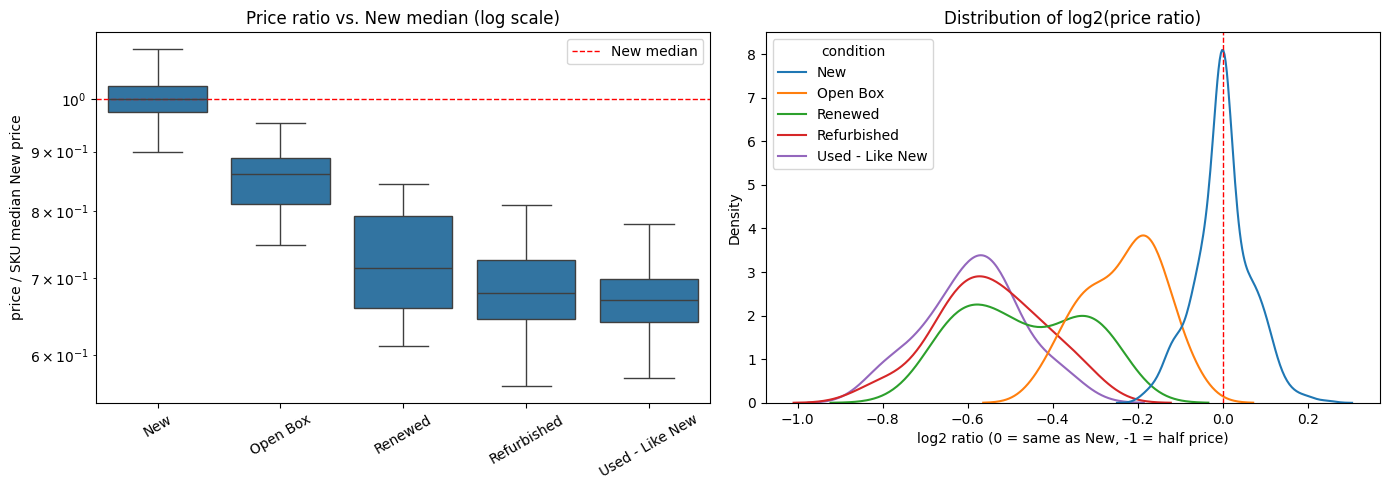

In [212]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MIN_NEW_LISTINGS = 3  # minimum New listings needed for a reliable baseline

# 1. Merge only the columns needed
ref = listing_ref_df[["listing_id", "true_sku_id"]]
assert ref["listing_id"].is_unique, "listing_ref_df has duplicate listing_id"

df = (
    listing_df[["listing_id", "condition_raw", "price_usd"]]
    .merge(ref, on="listing_id", how="inner", validate="m:1")
)

# 2. Normalize condition and check the categories
df["condition"] = df["condition_raw"].str.strip().str.title()
print(df["condition"].value_counts(dropna=False))

# 3. Baseline: per-SKU median price of New listings (broadcast back to every row)
is_new = df["condition"].eq("New")
new_prices = df["price_usd"].where(is_new)
grp = new_prices.groupby(df["true_sku_id"])

df["new_median"] = grp.transform("median")
df["new_count"] = grp.transform("count")

# 4. Ratio, keeping only valid rows
valid = (
    (df["new_count"] >= MIN_NEW_LISTINGS)
    & (df["price_usd"] > 0)
    & (df["new_median"] > 0)
)
print(f"Rows with usable baseline: {valid.mean():.1%} ({valid.sum():,} of {len(df):,})")

plot_df = df[valid].copy()
plot_df["price_ratio"] = plot_df["price_usd"] / plot_df["new_median"]
plot_df["log2_ratio"] = np.log2(plot_df["price_ratio"])  # symmetric: 0.5x and 2x are equidistant

# 5. Summary table (quantiles are more robust than min/max)
summary = (
    plot_df.groupby("condition")["price_ratio"]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .round(3)
)
print(summary)

# 6. Visualization
order = (
    plot_df.groupby("condition")["price_ratio"].median()
    .sort_values(ascending=False).index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot on log scale, outliers hidden
sns.boxplot(data=plot_df, x="condition", y="price_ratio", order=order,
            showfliers=False, ax=axes[0])
axes[0].set_yscale("log")
axes[0].axhline(1, color="red", ls="--", lw=1, label="New median")
axes[0].set(title="Price ratio vs. New median (log scale)",
            xlabel="", ylabel="price / SKU median New price")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# Distribution overlay
sns.kdeplot(data=plot_df, x="log2_ratio", hue="condition", hue_order=order,
            common_norm=False, clip=(-3, 3), ax=axes[1])
axes[1].axvline(0, color="red", ls="--", lw=1)
axes[1].set(title="Distribution of log2(price ratio)",
            xlabel="log2 ratio (0 = same as New, -1 = half price)")

plt.tight_layout()
plt.show()

In [301]:
'''
The fit - transform pattern is a common design pattern in machine leaning.
fit() lets you learn from training data and transform() lets you apply that knowledge to new data.

BaseEstimator gives you get_params()/set_params(), which sklearn uses for cloning and grid search.
TransformerMixin gives you fit_transform() for free, which just calls fit() then transform().

check_is_fitted raises an error if someone calls transform() before fit().

The leading underscore '_' signals "internal use."

'''
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted

DEFAULT_TIER = {"New": 0, "Open Box": 1, "Renewed": 2, "Refurbished": 2, "Used - Like New": 2}


class PairConditionPriceFeatures(BaseEstimator, TransformerMixin):
    """
    Condition and price features for listing pairs (A = *_x, B = *_y).

    fit():       learns per-condition discounts vs. the 'New' median price of the same SKU.
    transform(): builds symmetric features using the learned discounts.

    """

    _LISTING_COLS = ("condition_raw", "price_usd", "true_sku_id")

    def __init__(self, tier_map=None, min_price=0.01):
        self.tier_map = tier_map
        self.min_price = min_price

    _FEATURE_NAMES = (
        "cond_exact_match", "cond_tier_diff", "cond_missing",
        "log_price_min","log_price_max", "abs_log_price_diff", "price_min_max_ratio", "abs_log_price_diff_adj",)
    
    def get_feature_names_out(self, input_features=None):
        return np.array(self._FEATURE_NAMES)

    # ---------- helpers ----------
   
    @staticmethod
    def _norm(s: pd.Series) -> pd.Series:
        return s.str.strip().str.title()

    def _stack_listings(self, pairs: pd.DataFrame) -> pd.DataFrame:
        sides = [
            pairs[[f"{c}_{side}" for c in self._LISTING_COLS]]
            .set_axis(list(self._LISTING_COLS), axis=1)
            for side in ("x", "y")
        ]
        return pd.concat(sides, ignore_index=True)
    ''' 
            @staticmethod means the method doesn't use self. It's just a function living inside the class.
            .str.strip() removes leading and trailing spaces, and .str.title() capitalizes each word. So " open box " becomes "Open Box", which matches the dictionary keys.
            The : pd.Series and -> parts are type hints. They're documentation only and don't change behavior.
        
    '''

    # ---------- sklearn API ----------
    def fit(self, X: pd.DataFrame, y=None):
        listings = self._stack_listings(X)
        listings["condition_raw"] = self._norm(listings["condition_raw"])  # same keys as transform

        new_median = (
            listings.loc[listings["condition_raw"] == "New"]
            .groupby("true_sku_id")["price_usd"]
            .median()
        )
        listings["price_ratio"] = listings["price_usd"] / listings["true_sku_id"].map(new_median)

        '''The trailing underscore (discounts_) is the sklearn convention for "learned during fit." It's also what check_is_fitted looks for.'''
        self.discounts_ = listings.groupby("condition_raw")["price_ratio"].median().to_dict()
        self.tier_ = self.tier_map or DEFAULT_TIER
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        check_is_fitted(self, "discounts_")

        '''  
        ca/cb are the cleaned conditions for A and B.
        pa/pb are the prices, with anything below 0.01 raised to 0.01. This prevents log(0), which is -inf, and division by zero later.
        log_pa/log_pb are the log prices. Differences of logs measure relative price gaps (a $10 vs $20 gap counts like $100 vs $200).

        '''
        ca, cb = self._norm(X["condition_raw_x"]), self._norm(X["condition_raw_y"])
        pa = X["price_usd_x"].clip(lower=self.min_price)
        pb = X["price_usd_y"].clip(lower=self.min_price)
        log_pa, log_pb = np.log(pa), np.log(pb)

        f = pd.DataFrame(index=X.index)

        # Condition features
        '''  
        True/False becomes 1/0, stored as a small integer type.
        Convert each condition to its tier number, subtract, and take the absolute value. This is symmetric, so swapping A and B gives the same result. Conditions not in the dictionary become NaN.
        Flags 1 if either condition is missing. | is "or" for pandas boolean Series.

        '''
        f["cond_exact_match"] = (ca == cb).astype("int8")
        f["cond_tier_diff"] = (ca.map(self.tier_) - cb.map(self.tier_)).abs()  # NaN if unknown
        f["cond_missing"] = (ca.isna() | cb.isna()).astype("int8")

        # Raw price features (symmetric in A/B)
        ''' 
        min max symmetric log price features 
        abs_log_price_diff tells far apart the prices are on a log scale.
        price_min_max_ratio is cheaper price ÷ pricier price, between 0 and 1, where 1 means identical prices. np.minimum/np.maximum work row by row. Both features are symmetric in A and B.
    
        '''
        f["log_price_min"] = np.minimum(log_pa, log_pb)
        f["log_price_max"] = np.maximum(log_pa, log_pb)
        f["abs_log_price_diff"] = (log_pa - log_pb).abs()
        f["price_min_max_ratio"] = np.minimum(pa, pb) / np.maximum(pa, pb)

        # Condition-adjusted price: compare as if both were New
        ''' 
        Since log(p) - log(d) = log(p / d), this divides each price by its condition's typical discount, 
        giving an estimate of "what would this cost if it were New?" The final feature is the log gap between those adjusted prices. 
        If a used item and a new item are really the same product, this gap should be small even though the raw prices differ.
        '''
        adj_a = log_pa - np.log(ca.map(self.discounts_))
        adj_b = log_pb - np.log(cb.map(self.discounts_))
        f["abs_log_price_diff_adj"] = (adj_a - adj_b).abs()

        '''  
        Feature	                Range	        Closer to...                        
        abs_log_price_diff	    0 to ∞	        0 = same price
        price_min_max_ratio	    0 to 1	        1 = same price
        abs_log_price_diff_adj	0 to ∞	        0 = same price after adjusting

        '''

        return f

In [306]:
from sklearn.pipeline import FeatureUnion

feature_builder = FeatureUnion(
    [
        ("cond_price", PairConditionPriceFeatures()),
        # ("title_sim", PairTitleSimilarityFeatures()),
        # ("brand",     PairBrandFeatures()),
    ],
    verbose_feature_names_out=False,
).set_output(transform="pandas")


# This will now successfully return a pandas DataFrame
feats = feature_builder.fit_transform(final)
feats.head()


,cond_exact_match,cond_tier_diff,cond_missing,log_price_min,log_price_max,abs_log_price_diff,price_min_max_ratio,abs_log_price_diff_adj
0,0,1,0,7.0678,7.1560,0.0882,0.9155,0.2452
1,0,2,0,6.2579,6.6026,0.3447,0.7084,0.0159
2,0,2,0,2.4791,5.7870,3.3079,0.0366,2.9790
3,0,2,0,2.5392,7.4857,4.9465,0.0071,4.5458
4,0,2,0,6.9313,7.1399,0.2086,0.8117,0.1203
